In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel(
    "3.ORC Star Store List JuL17.xlsx",
    sheet_name="Store STAR List",
    header=[0, 1]
)

print("Dataset Loaded")

Dataset Loaded


In [3]:
new_columns = []

for col in df.columns:

    if isinstance(col, tuple):

        col = [
            str(x)
            for x in col
            if (
                "Unnamed" not in str(x)
                and "level" not in str(x)
            )
        ]

        new_columns.append(
            "_".join(col)
        )

    else:
        new_columns.append(
            str(col)
        )

df.columns = new_columns

print(df.columns)

Index(['Store Type', 'Category', 'Store Name', 'Store Id', 'Division',
       'retailer_name', 'Region', 'Banner Region', 'Province', 'City',
       'store_number_1', 'STAR-5', 'STAR-3', 'PSTAR-5', 'PSTAR-3',
       'Length%_2017-05-01 00:00:00', 'Length%_2017-06-01 00:00:00',
       'Length%_2017-07-01 00:00:00', 'Facings%_2017-05-01 00:00:00',
       'Facings%_2017-06-01 00:00:00', 'Facings%_2017-07-01 00:00:00',
       'DisplayS%_2017-05-01 00:00:00', 'DisplayS%_2017-06-01 00:00:00',
       'DisplayS%_2017-07-01 00:00:00', 'PSKU%_2017-05-01 00:00:00',
       'PSKU%_2017-06-01 00:00:00', 'PSKU%_2017-07-01 00:00:00',
       'Star_2017-05-01 00:00:00', 'Star_2017-06-01 00:00:00',
       'Star_2017-07-01 00:00:00', 'Star_Star JAS Base', 'Star_PG Manager',
       'Star_PG Manager.1', 'Colour Coding', 'Colour Coding_[STAR-3,STAR-5)'],
      dtype='object')


In [4]:
# Understand the Column
print(df.columns.tolist()) 

['Store Type', 'Category', 'Store Name', 'Store Id', 'Division', 'retailer_name', 'Region', 'Banner Region', 'Province', 'City', 'store_number_1', 'STAR-5', 'STAR-3', 'PSTAR-5', 'PSTAR-3', 'Length%_2017-05-01 00:00:00', 'Length%_2017-06-01 00:00:00', 'Length%_2017-07-01 00:00:00', 'Facings%_2017-05-01 00:00:00', 'Facings%_2017-06-01 00:00:00', 'Facings%_2017-07-01 00:00:00', 'DisplayS%_2017-05-01 00:00:00', 'DisplayS%_2017-06-01 00:00:00', 'DisplayS%_2017-07-01 00:00:00', 'PSKU%_2017-05-01 00:00:00', 'PSKU%_2017-06-01 00:00:00', 'PSKU%_2017-07-01 00:00:00', 'Star_2017-05-01 00:00:00', 'Star_2017-06-01 00:00:00', 'Star_2017-07-01 00:00:00', 'Star_Star JAS Base', 'Star_PG Manager', 'Star_PG Manager.1', 'Colour Coding', 'Colour Coding_[STAR-3,STAR-5)']


In [5]:
df.head() #First few Rows

,Store Type,Category,Store Name,Store Id,Division,retailer_name,Region,Banner Region,Province,City,...,PSKU%_2017-06-01 00:00:00,PSKU%_2017-07-01 00:00:00,Star_2017-05-01 00:00:00,Star_2017-06-01 00:00:00,Star_2017-07-01 00:00:00,Star_Star JAS Base,Star_PG Manager,Star_PG Manager.1,Colour Coding,"Colour Coding_[STAR-3,STAR-5)"
0,C&C,Baby_婴儿纸尿裤,11187 - 锦江麦德龙先购自运有限公司南京下关商场,11187,Division 1,Metro,East,Metro-E,江苏,南京,...,36.0,40.0,★,★,NaN,★,NaN,NaN,NaN,"[0,STAR-3)"
1,C&C,Baby_婴儿纸尿裤,11574 - 锦江麦德龙现购自运有限公司广州白云商场,11574,Division 1,Metro,South,Metro-S&W,广东,广州,...,84.0,80.0,★★★★★,★★★★★,NaN,NaN,NaN,NaN,NaN,NaN
2,C&C,Baby_婴儿纸尿裤,11741 - 锦江麦德龙现购自运有限公司烟台芝罘商场,11741,Division 1,Metro,North,Metro-N,山东,烟台,...,64.0,44.0,★,★★★,NaN,NaN,NaN,NaN,NaN,NaN
3,C&C,Baby_婴儿纸尿裤,11816 - 锦江麦德龙现购自运有限公司深圳宝安商场,11816,Division 1,Metro,South,Metro-S&W,广东,深圳,...,64.0,72.0,★★★,★★★,★★★,NaN,NaN,NaN,NaN,NaN
4,C&C,Baby_婴儿纸尿裤,24 - 锦江麦德龙现购自运有限公司长沙开福商场,24,Division 1,Metro,West,Metro-S&W,湖南,长沙,...,88.0,88.0,★★★,★★★,★★★★★,NaN,NaN,NaN,NaN,NaN


In [6]:
df.tail() #Last few rows

,Store Type,Category,Store Name,Store Id,Division,retailer_name,Region,Banner Region,Province,City,...,PSKU%_2017-06-01 00:00:00,PSKU%_2017-07-01 00:00:00,Star_2017-05-01 00:00:00,Star_2017-06-01 00:00:00,Star_2017-07-01 00:00:00,Star_Star JAS Base,Star_PG Manager,Star_PG Manager.1,Colour Coding,"Colour Coding_[STAR-3,STAR-5)"
34828,Super West,Skin_护肤,35650 - 新世纪巫溪店,35650,Division 3,CQ Xinshiji,West,CQ Xinshiji,重庆,重庆,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34829,Super West,Skin_护肤,38207 - 步步高重庆汇祥幸福里店,38207,Division 3,BBG,West,Hunan,重庆,重庆,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34830,Super West,Skin_护肤,40064 - 步步高邵阳市隆回店,40064,Division 3,BBG,West,Hunan,湖南,邵阳,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34831,Super West,Skin_护肤,5992 - 武商荆州中山店,5992,Division 3,WH Wushang,West,WH,湖北,荆州,...,NaN,95.466486,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34832,Super West,Skin_护肤,5692 - 中百仓储麻城店,5692,Division 3,WH Zhongbai,West,WHZB,湖北,麻城,...,NaN,66.666667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
print(df.shape) #Dimension of the dataset

(34833, 35)


In [8]:
# Understand the data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34833 entries, 0 to 34832
Data columns (total 35 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Store Type                     34833 non-null  object 
 1   Category                       34833 non-null  object 
 2   Store Name                     34833 non-null  object 
 3   Store Id                       34833 non-null  int64  
 4   Division                       34833 non-null  object 
 5   retailer_name                  34833 non-null  object 
 6   Region                         34833 non-null  object 
 7   Banner Region                  34833 non-null  object 
 8   Province                       34833 non-null  object 
 9   City                           34833 non-null  object 
 10  store_number_1                 34833 non-null  int64  
 11  STAR-5                         34833 non-null  float64
 12  STAR-3                         34833 non-null 

In [9]:
df.describe() #Statistical summary

,Store Id,store_number_1,STAR-5,STAR-3,PSTAR-5,PSTAR-3,Length%_2017-05-01 00:00:00,Length%_2017-06-01 00:00:00,Length%_2017-07-01 00:00:00,Facings%_2017-05-01 00:00:00,...,Facings%_2017-07-01 00:00:00,DisplayS%_2017-05-01 00:00:00,DisplayS%_2017-06-01 00:00:00,DisplayS%_2017-07-01 00:00:00,PSKU%_2017-05-01 00:00:00,PSKU%_2017-06-01 00:00:00,PSKU%_2017-07-01 00:00:00,Star_PG Manager,Star_PG Manager.1,Colour Coding
count,34833.000000,34833.000000,34833.000000,34833.000000,34833.0,34833.000000,22976.000000,23779.000000,20134.000000,22976.000000,...,20134.000000,20564.000000,20764.000000,20485.000000,28163.000000,30344.000000,27913.000000,0.0,0.0,0.0
mean,18248.527689,18248.527689,28.945267,20.935980,80.0,57.357965,28.099476,27.717463,26.375005,27.457365,...,25.826093,29.631446,29.918700,29.453855,71.878268,68.421394,68.936910,NaN,NaN,NaN
std,14225.324177,14225.324177,25.325620,18.949844,0.0,4.409145,22.864628,22.749623,21.624369,22.823461,...,21.579426,30.039498,30.578073,30.245872,23.662765,24.661200,22.290044,NaN,NaN,NaN
min,2.000000,2.000000,3.000000,2.500000,80.0,50.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN
25%,4752.000000,4752.000000,10.000000,8.000000,80.0,50.000000,12.540000,12.340000,11.930000,11.320000,...,10.752500,2.297500,2.040000,1.830000,59.090909,54.550000,57.142857,NaN,NaN,NaN
50%,11936.000000,11936.000000,23.000000,15.000000,80.0,60.000000,21.930000,21.380000,20.790000,21.240000,...,20.210000,21.680000,21.545000,21.260000,76.923077,73.080000,72.727273,NaN,NaN,NaN
75%,33285.000000,33285.000000,41.000000,25.000000,80.0,60.000000,34.630000,34.060000,32.347500,34.870000,...,32.690000,45.405000,45.830000,45.220000,90.050667,87.500000,85.714286,NaN,NaN,NaN
max,40692.000000,40692.000000,87.000000,70.000000,80.0,60.000000,100.080000,100.080000,100.000000,100.000000,...,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,NaN,NaN,NaN


In [10]:
# Missing Value Analysis 
print(df.isnull().sum())

Store Type                           0
Category                             0
Store Name                           0
Store Id                             0
Division                             0
retailer_name                        0
Region                               0
Banner Region                        0
Province                             0
City                                 0
store_number_1                       0
STAR-5                               0
STAR-3                               0
PSTAR-5                              0
PSTAR-3                              0
Length%_2017-05-01 00:00:00      11857
Length%_2017-06-01 00:00:00      11054
Length%_2017-07-01 00:00:00      14699
Facings%_2017-05-01 00:00:00     11857
Facings%_2017-06-01 00:00:00     11054
Facings%_2017-07-01 00:00:00     14699
DisplayS%_2017-05-01 00:00:00    14269
DisplayS%_2017-06-01 00:00:00    14069
DisplayS%_2017-07-01 00:00:00    14348
PSKU%_2017-05-01 00:00:00         6670
PSKU%_2017-06-01 00:00:00

Colour Coding                    100.000000
Star_PG Manager.1                100.000000
Star_PG Manager                  100.000000
Colour Coding_[STAR-3,STAR-5)     99.997129
Star_2017-07-01 00:00:00          48.293285
Star_Star JAS Base                47.058824
Star_2017-05-01 00:00:00          43.071226
Facings%_2017-07-01 00:00:00      42.198490
Length%_2017-07-01 00:00:00       42.198490
DisplayS%_2017-07-01 00:00:00     41.190825
DisplayS%_2017-05-01 00:00:00     40.964028
Star_2017-06-01 00:00:00          40.694169
DisplayS%_2017-06-01 00:00:00     40.389860
Facings%_2017-05-01 00:00:00      34.039560
Length%_2017-05-01 00:00:00       34.039560
Facings%_2017-06-01 00:00:00      31.734275
Length%_2017-06-01 00:00:00       31.734275
PSKU%_2017-07-01 00:00:00         19.866219
PSKU%_2017-05-01 00:00:00         19.148509
PSKU%_2017-06-01 00:00:00         12.887205
Store Name                         0.000000
Store Type                         0.000000
Category                        

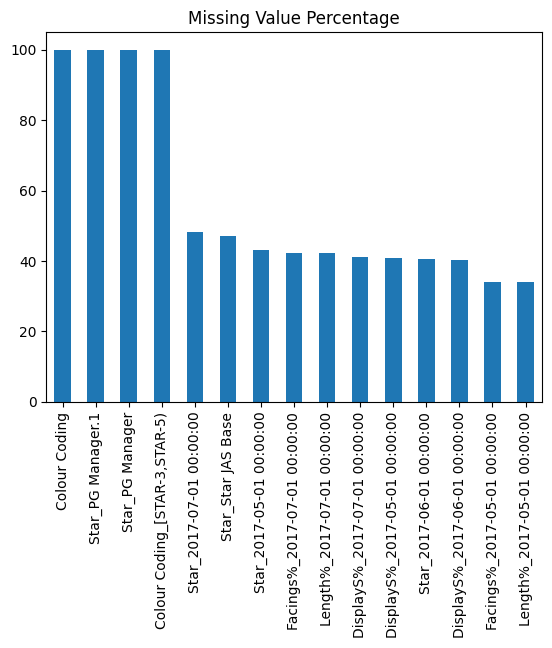

In [11]:
# Missing Value Percentage

missing_percent = (
    df.isnull()
    .mean()
    * 100
).sort_values(
    ascending=False
)

print(missing_percent)

missing_percent.head(15).plot(
    kind="bar"
)

plt.title(
    "Missing Value Percentage"
)

plt.show()

In [12]:
# Drop 100% Missing values

drop_cols = [
"Star_PG Manager", "Star_PG Manager.1",
       "Colour Coding",
"Colour Coding_[STAR-3,STAR-5)"
]

df.drop(
    columns=drop_cols,
    inplace=True
)

print(df.shape)

(34833, 31)


In [13]:
# Duplicate Check

print(
    "Duplicate rows:",
    df.duplicated().sum()
)

Duplicate rows: 0


In [14]:
#Check where store id and store number 1 same
(
df["Store Id"]
==
df["store_number_1"]
).all()

np.True_

In [15]:
#Drop store number 1 attribute
df.drop(
    columns=["store_number_1"],
    inplace=True
)

print(df.shape)
print(df.columns)

(34833, 30)
Index(['Store Type', 'Category', 'Store Name', 'Store Id', 'Division',
       'retailer_name', 'Region', 'Banner Region', 'Province', 'City',
       'STAR-5', 'STAR-3', 'PSTAR-5', 'PSTAR-3', 'Length%_2017-05-01 00:00:00',
       'Length%_2017-06-01 00:00:00', 'Length%_2017-07-01 00:00:00',
       'Facings%_2017-05-01 00:00:00', 'Facings%_2017-06-01 00:00:00',
       'Facings%_2017-07-01 00:00:00', 'DisplayS%_2017-05-01 00:00:00',
       'DisplayS%_2017-06-01 00:00:00', 'DisplayS%_2017-07-01 00:00:00',
       'PSKU%_2017-05-01 00:00:00', 'PSKU%_2017-06-01 00:00:00',
       'PSKU%_2017-07-01 00:00:00', 'Star_2017-05-01 00:00:00',
       'Star_2017-06-01 00:00:00', 'Star_2017-07-01 00:00:00',
       'Star_Star JAS Base'],
      dtype='object')


In [16]:
# Check uniqueness of every column

for col in df.columns:
    
    unique = df[col].nunique()
    total = len(df)

    print(
        f"{col}  →  {unique}/{total}"
    )

Store Type  →  7/34833
Category  →  8/34833
Store Name  →  4081/34833
Store Id  →  4081/34833
Division  →  6/34833
retailer_name  →  37/34833
Region  →  4/34833
Banner Region  →  111/34833
Province  →  30/34833
City  →  463/34833
STAR-5  →  14/34833
STAR-3  →  11/34833
PSTAR-5  →  1/34833
PSTAR-3  →  2/34833
Length%_2017-05-01 00:00:00  →  6560/34833
Length%_2017-06-01 00:00:00  →  6561/34833
Length%_2017-07-01 00:00:00  →  6048/34833
Facings%_2017-05-01 00:00:00  →  5768/34833
Facings%_2017-06-01 00:00:00  →  5786/34833
Facings%_2017-07-01 00:00:00  →  5509/34833
DisplayS%_2017-05-01 00:00:00  →  6184/34833
DisplayS%_2017-06-01 00:00:00  →  6277/34833
DisplayS%_2017-07-01 00:00:00  →  6181/34833
PSKU%_2017-05-01 00:00:00  →  800/34833
PSKU%_2017-06-01 00:00:00  →  1462/34833
PSKU%_2017-07-01 00:00:00  →  2018/34833
Star_2017-05-01 00:00:00  →  3/34833
Star_2017-06-01 00:00:00  →  3/34833
Star_2017-07-01 00:00:00  →  3/34833
Star_Star JAS Base  →  3/34833


In [17]:
# Finding the composite unique key
key_cols = [
"Store Id",
"Category",
"DisplayS%_2017-06-01 00:00:00",
"DisplayS%_2017-07-01 00:00:00",
"PSKU%_2017-06-01 00:00:00",
"PSKU%_2017-07-01 00:00:00",
]

print(
    "Unique rows:",
    df[key_cols]
    .drop_duplicates()
    .shape[0]
)

print(
    "Total rows:",
    len(df)
)

Unique rows: 34833
Total rows: 34833


In [18]:
#Understand Categorical columns
print("Region:")
print(df["Region"].unique())
df["Region"].value_counts()


Region:
['East' 'South' 'North' 'West']


Region
West     10337
East      9563
North     8059
South     6874
Name: count, dtype: int64

In [19]:
print("Division:")
print(df["Division"].unique())
df["Division"].value_counts()

Division:
['Division 1' 'Division 5' 'Division 2' 'Division 3' 'Division 4' 'DPSC-H']


Division
Division 3    9886
Division 2    8940
Division 1    6520
Division 4    5839
Division 5    3488
DPSC-H         160
Name: count, dtype: int64

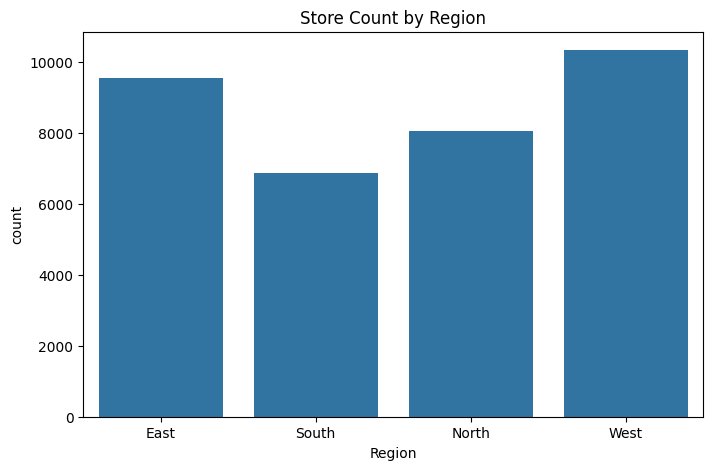

In [20]:
# Univariate Analysis

plt.figure(figsize=(8,5))

sns.countplot(
    x="Region",
    data=df
)

plt.title(
    "Store Count by Region"
)

plt.show()

Region
East     25.550261
North    27.428309
South    26.844938
West     26.013467
Name: Length%_2017-07-01 00:00:00, dtype: float64


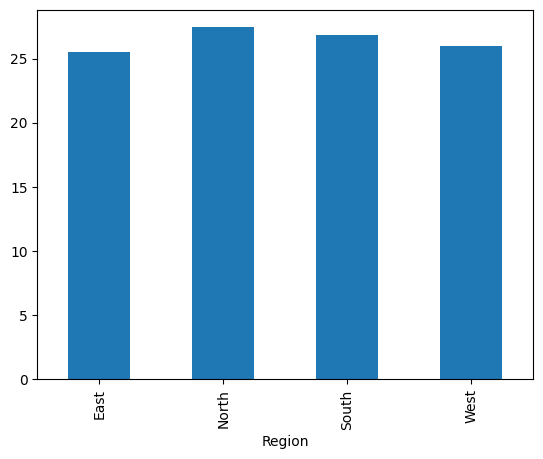

In [21]:
#Bivariate Analysis - Average Length By region

avg = (
    df.groupby(
        "Region"
    )[
        "Length%_2017-07-01 00:00:00"
    ]
    .mean()
)

print(avg)

avg.plot(
    kind="bar"
)

plt.show()

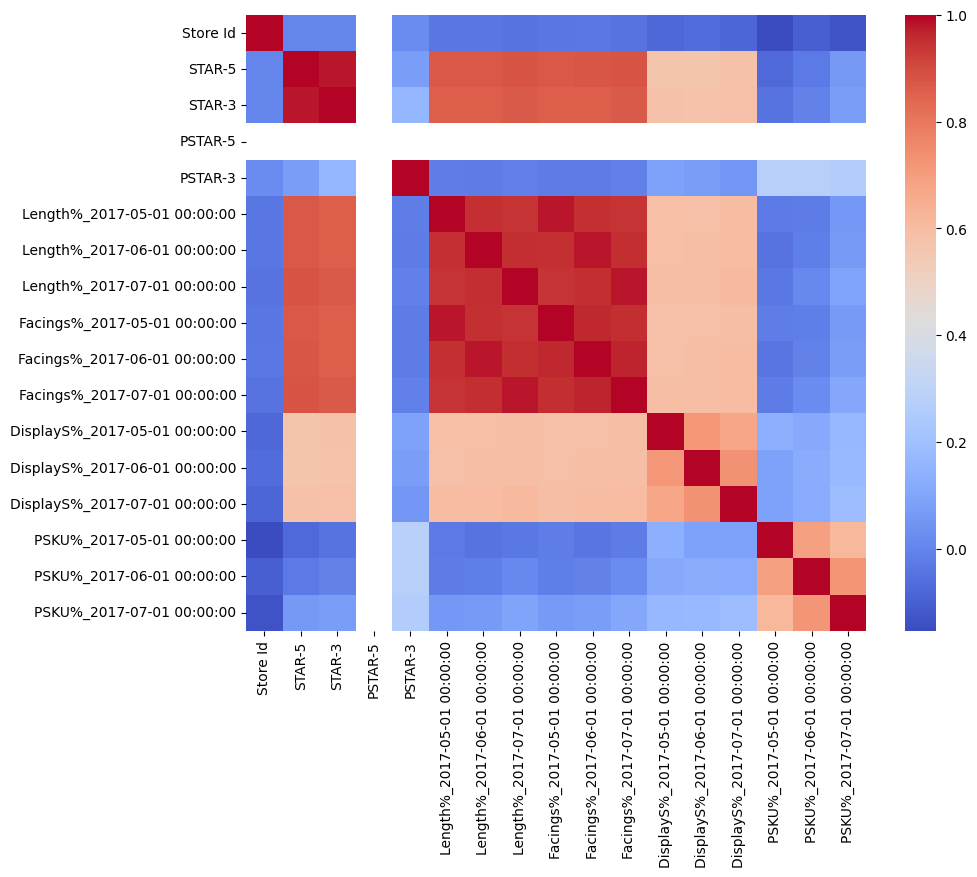

In [22]:
# Correlation

num = df.select_dtypes(
    include=np.number
)

corr = num.corr()

plt.figure(
    figsize=(10,8)
)

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.show()

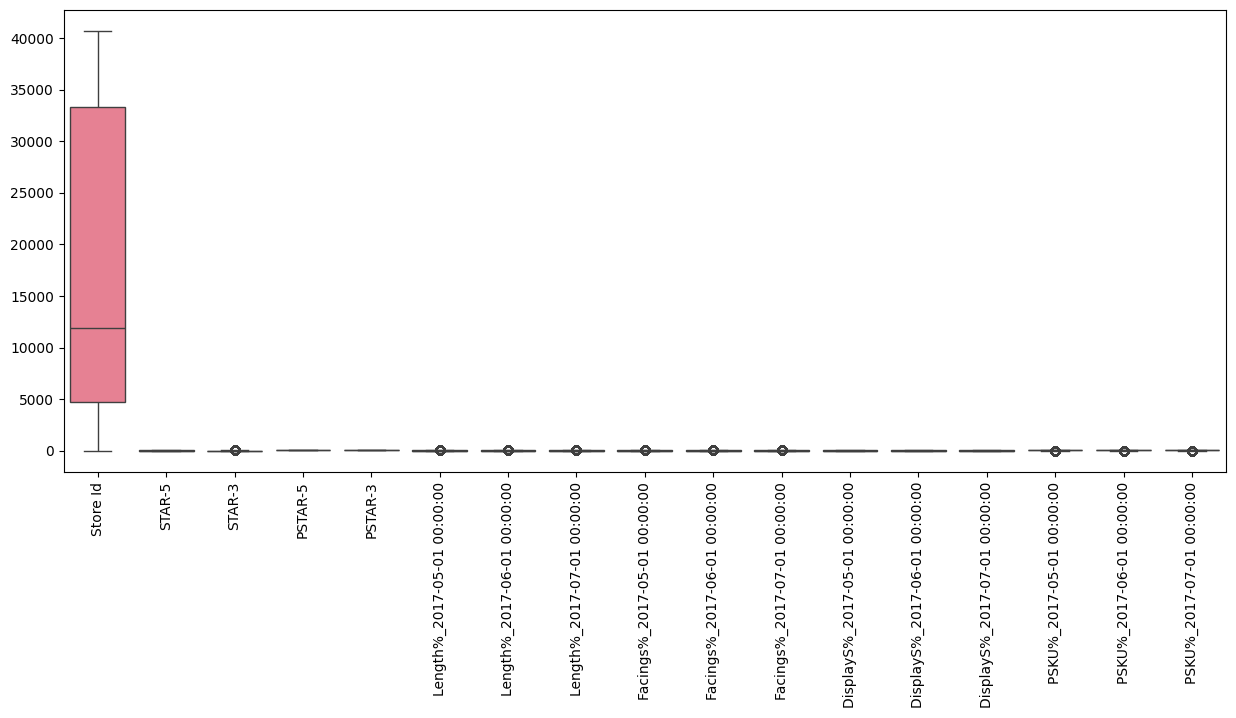

In [23]:
# Outlier Detection on numeric data

num_cols = df.select_dtypes(
    include=np.number
)

plt.figure(
    figsize=(15,6)
)

sns.boxplot(
    data=num_cols
)

plt.xticks(
    rotation=90
)

plt.show()

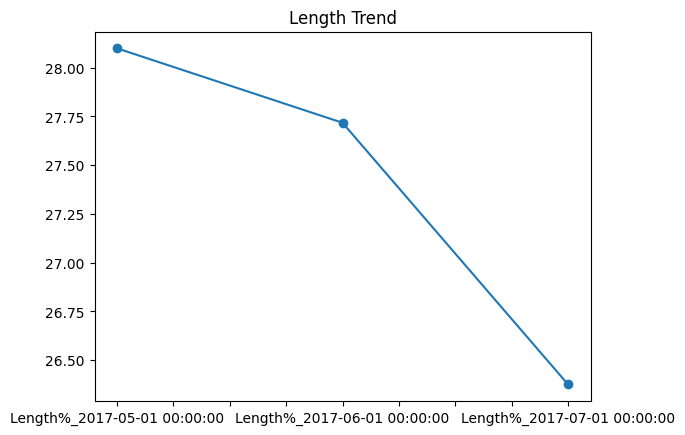

In [24]:
# Month comparison for Lengths

metrics = [
"Length%_2017-05-01 00:00:00",
"Length%_2017-06-01 00:00:00",
"Length%_2017-07-01 00:00:00"
]

df[metrics].mean().plot(
    marker="o"
)

plt.title(
    "Length Trend"
)

plt.show()

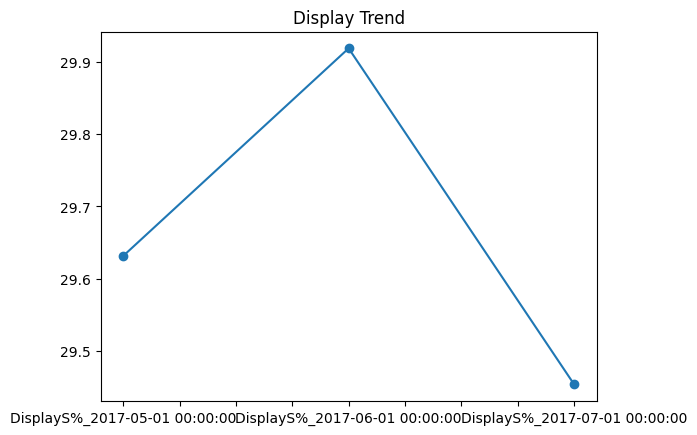

In [25]:
#Month comparison for DisplayS

metrics = [
"DisplayS%_2017-05-01 00:00:00",
"DisplayS%_2017-06-01 00:00:00",
"DisplayS%_2017-07-01 00:00:00"
]

df[metrics].mean().plot(
    marker="o"
)

plt.title(
    "Display Trend"
)

plt.show()

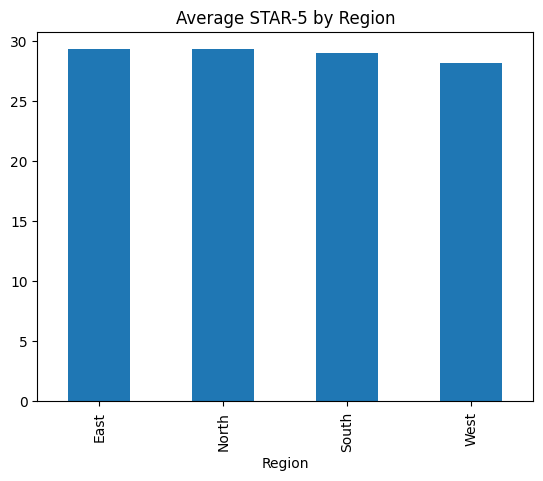

In [26]:
#Region and Metric Comparison

region_star = (
    df.groupby("Region")
    ["STAR-5"]
    .mean()
)

region_star.plot(
    kind="bar"
)

plt.title(
    "Average STAR-5 by Region"
)

plt.show()

C:\Users\vinyt\tfenv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20010 (\N{CJK UNIFIED IDEOGRAPH-4E2A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\vinyt\tfenv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20154 (\N{CJK UNIFIED IDEOGRAPH-4EBA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\vinyt\tfenv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 28165 (\N{CJK UNIFIED IDEOGRAPH-6E05}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\vinyt\tfenv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27905 (\N{CJK UNIFIED IDEOGRAPH-6D01}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\vinyt\tfenv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25252 (\N{CJK UNIFIED IDEOGRAPH-62A4}) missing from font(s) DejaVu Sans.
  fig.canvas.prin

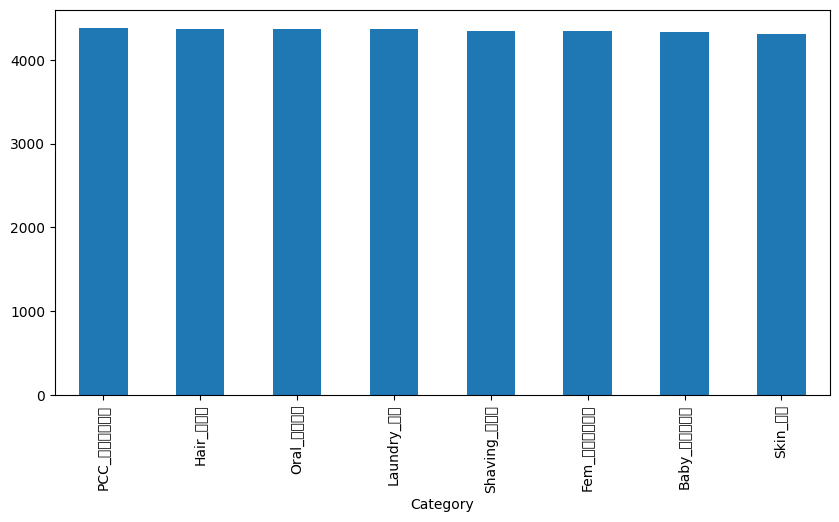

In [27]:
# Category Analysis

plt.figure(
    figsize=(10,5)
)

df["Category"]\
.value_counts()\
.head(10)\
.plot(
kind="bar"
)

plt.show()

In [28]:
# Compare Actual vs Target STAR

df["STAR5_Achievement"] = (
    df["STAR-5"] /
    df["PSTAR-5"]
) * 100

df["STAR3_Achievement"] = (
    df["STAR-3"] /
    df["PSTAR-3"]
) * 100

df[
[
"STAR5_Achievement",
"STAR3_Achievement"
]
].describe()

,STAR5_Achievement,STAR3_Achievement
count,34833.000000,34833.000000
mean,36.181584,36.286749
std,31.657025,32.372535
min,3.750000,5.000000
25%,12.500000,13.333333
50%,28.750000,30.000000
75%,51.250000,50.000000
max,108.750000,116.666667


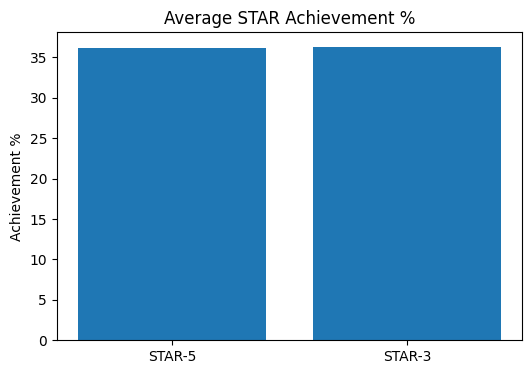

In [29]:
# Plot Comparison for STAR
achievement = [
df["STAR5_Achievement"].mean(),
df["STAR3_Achievement"].mean()
]

plt.figure(figsize=(6,4))

plt.bar(
["STAR-5","STAR-3"],
achievement
)

plt.title(
"Average STAR Achievement %"
)

plt.ylabel("Achievement %")

plt.show()

In [30]:
# Save it locally
df.to_excel(
    "clean_store_data.xlsx",
    index=False
)

print("Excel file saved successfully")

Excel file saved successfully
